# Loan Default Prediction
A machine learning project using real Nigerian lending data (OneFi/Data Science Nigeria) to predict whether a borrower will default on a loan.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading
Loading and merging three datasets: loan performance, borrower demographics, and previous loan history using customerid as the key

In [3]:
trainperf = pd.read_csv('trainperf.csv')
traindemographics = pd.read_csv('traindemographics.csv')
trainprevloans = pd.read_csv('trainprevloans.csv')

df = trainperf.merge(traindemographics, on='customerid', how='left')
df = df.merge(trainprevloans, on='customerid', how='left')

## 2. Data Cleaning
Handling missing values, dropping low-quality columns and engineering the age feature from birthdate

In [4]:
print(df.shape)
df.info()

(18212, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18212 entries, 0 to 18211
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customerid                  18212 non-null  object 
 1   systemloanid_x              18212 non-null  int64  
 2   loannumber_x                18212 non-null  int64  
 3   approveddate_x              18212 non-null  object 
 4   creationdate_x              18212 non-null  object 
 5   loanamount_x                18212 non-null  float64
 6   totaldue_x                  18212 non-null  float64
 7   termdays_x                  18212 non-null  int64  
 8   referredby_x                1028 non-null   object 
 9   good_bad_flag               18212 non-null  object 
 10  birthdate                   13698 non-null  object 
 11  bank_account_type           13698 non-null  object 
 12  longitude_gps               13698 non-null  float64
 13  latitude_gps       

In [5]:
df = df.drop(columns=['referredby_x', 'bank_branch_clients'])

In [6]:
print(df['good_bad_flag'].value_counts())

good_bad_flag
Good    14840
Bad      3372
Name: count, dtype: int64


In [7]:
# Fill categorical columns
cat_cols = ['bank_account_type', 'bank_name_clients', 
            'employment_status_clients', 'level_of_education_clients']
df[cat_cols] = df[cat_cols].fillna('Unknown')

# Fill GPS with median
df = df.drop(columns=['longitude_gps', 'latitude_gps'])

# Convert birthdate to age
df['birthdate'] = pd.to_datetime(df['birthdate'])
df['age'] = 2017 - df['birthdate'].dt.year
df['age'] = df['age'].fillna(df['age'].median())

In [8]:
df.isnull().sum()

customerid                        0
systemloanid_x                    0
loannumber_x                      0
approveddate_x                    0
creationdate_x                    0
loanamount_x                      0
totaldue_x                        0
termdays_x                        0
good_bad_flag                     0
birthdate                      4514
bank_account_type                 0
bank_name_clients                 0
employment_status_clients         0
level_of_education_clients        0
systemloanid_y                    9
loannumber_y                      9
approveddate_y                    9
creationdate_y                    9
loanamount_y                      9
totaldue_y                        9
termdays_y                        9
closeddate                        9
referredby_y                  17184
firstduedate                      9
firstrepaiddate                   9
age                               0
dtype: int64

In [9]:
# Drop remaining problem columns
df = df.drop(columns=['birthdate', 'firstduedate'])

# Fill _y column nulls with 0
y_cols = ['loannumber_y', 'approveddate_y', 'creationdate_y', 
          'loanamount_y', 'totaldue_y', 'termdays_y', 
          'closeddate', 'referredby_y', 'firstrepaiddate']
df[y_cols] = df[y_cols].fillna(0)

# Verify
print(df.shape)
df.isnull().sum()

(18212, 24)


customerid                    0
systemloanid_x                0
loannumber_x                  0
approveddate_x                0
creationdate_x                0
loanamount_x                  0
totaldue_x                    0
termdays_x                    0
good_bad_flag                 0
bank_account_type             0
bank_name_clients             0
employment_status_clients     0
level_of_education_clients    0
systemloanid_y                9
loannumber_y                  0
approveddate_y                0
creationdate_y                0
loanamount_y                  0
totaldue_y                    0
termdays_y                    0
closeddate                    0
referredby_y                  0
firstrepaiddate               0
age                           0
dtype: int64

## 3. Exploratory Data Analysis
Visualizing key patterns including loan distribution, borrower demographics, default rates and employment status breakdown.

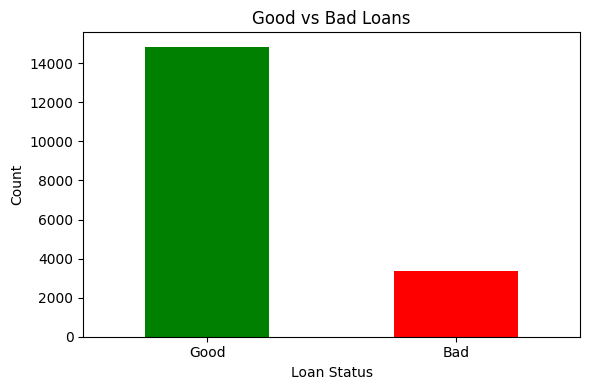

In [10]:
df['good_bad_flag'].value_counts().plot(kind='bar', color=['green', 'red'], figsize=(6,4))
plt.title('Good vs Bad Loans')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

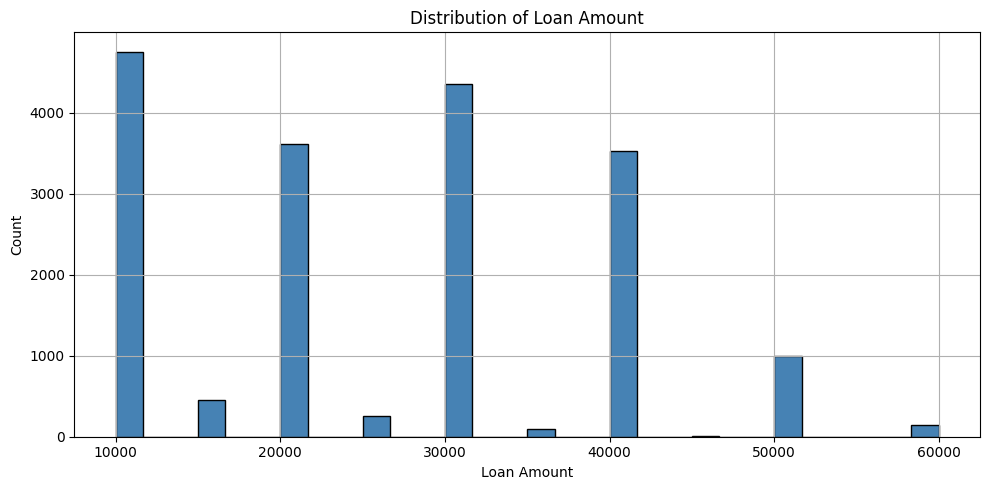

In [11]:
df['loanamount_x'].hist(bins=30, color='steelblue', edgecolor='black', figsize=(10,5))
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

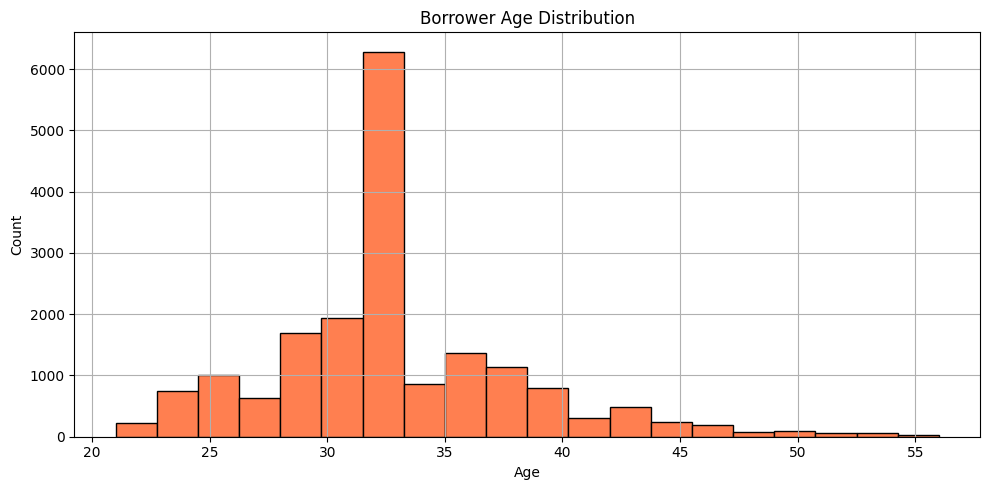

In [12]:
df['age'].hist(bins=20, figsize=(10,5), color='coral', edgecolor='black')
plt.title('Borrower Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

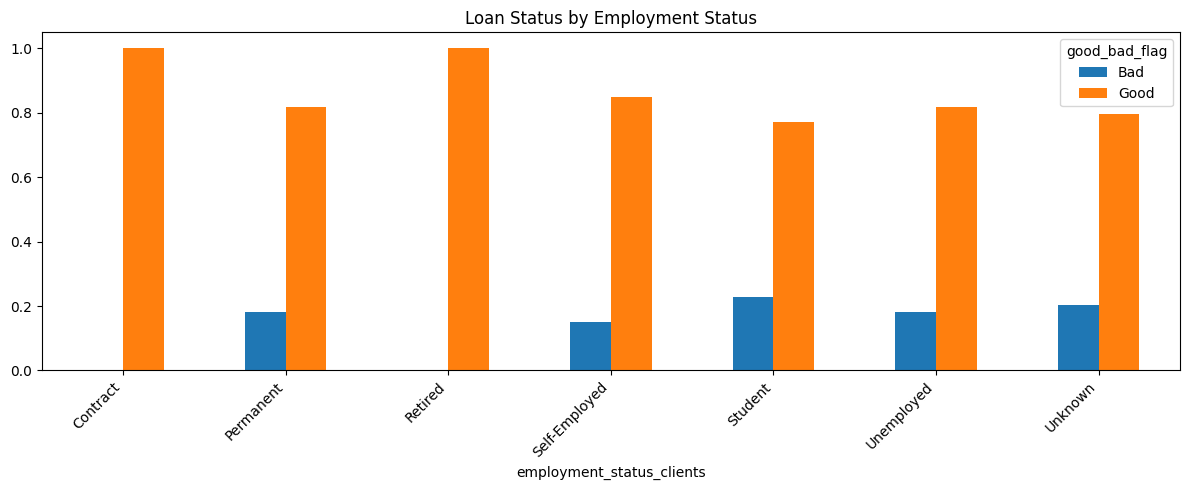

In [13]:
df.groupby('employment_status_clients')['good_bad_flag'].value_counts(normalize=True).unstack().plot(kind='bar', figsize=(12,5))
plt.title('Loan Status by Employment Status')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Feature Engineering
Creating new columns from existing columns to improve model performance, including interest rate, daily payment burden and repeat borrower flag

In [14]:
df['interest_rate'] = (df['totaldue_x'] - df['loanamount_x']) / df['loanamount_x']
# 2. Loan to term ratio (how much they pay per day)
df['daily_payment'] = df['totaldue_x'] / df['termdays_x']

# 3. Repeat borrower flag (have they taken loans before?)
df['is_repeat_borrower'] = (df['loannumber_x'] > 1).astype(int)

# 4. Previous loan default rate (how reliable were they before?)
df['prev_loan_amount'] = df['loanamount_y'].fillna(0)

# 5. Encode target variable as binary
df['target'] = (df['good_bad_flag'] == 'Good').astype(int)

# Verify new columns
print(df[['interest_rate', 'daily_payment', 'is_repeat_borrower', 'target']].head(10))

   interest_rate  daily_payment  is_repeat_borrower  target
0           0.15         1150.0                   1       1
1           0.15         1150.0                   1       1
2           0.15         1150.0                   1       1
3           0.15         1150.0                   1       1
4           0.15         1150.0                   1       1
5           0.15         1150.0                   1       1
6           0.15         1150.0                   1       1
7           0.15         1150.0                   1       1
8           0.15         1150.0                   1       1
9           0.15         1150.0                   1       1


## 5. Handling Class Imbalance

In [15]:
from sklearn.preprocessing import LabelEncoder

# Drop columns not useful for modelling
drop_cols = ['customerid', 'good_bad_flag', 'approveddate_x', 
             'creationdate_x', 'approveddate_y', 'creationdate_y',
             'closeddate', 'firstrepaiddate', 'referredby_y',
             'systemloanid_x', 'systemloanid_y']

df_model = df.drop(columns=drop_cols)

# Encode categorical columns
cat_cols = ['bank_account_type', 'bank_name_clients', 
            'employment_status_clients', 'level_of_education_clients']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print(df_model.shape)
print(df_model.dtypes)

(18212, 18)
loannumber_x                    int64
loanamount_x                  float64
totaldue_x                    float64
termdays_x                      int64
bank_account_type               int64
bank_name_clients               int64
employment_status_clients       int64
level_of_education_clients      int64
loannumber_y                  float64
loanamount_y                  float64
totaldue_y                    float64
termdays_y                    float64
age                           float64
interest_rate                 float64
daily_payment                 float64
is_repeat_borrower              int64
prev_loan_amount              float64
target                          int64
dtype: object


In [16]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separate features and target
X = df_model.drop(columns=['target'])
y = df_model['target']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check class balance after SMOTE
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_resampled.value_counts().to_dict())

Before SMOTE: {1: 11855, 0: 2714}
After SMOTE: {1: 11855, 0: 11855}


## 6. Model Training and Comparison
Training and Comparing three classification models: Logistic Regression, Random Forest and XGBoost

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Logistic Regression
lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)
lr_preds = lr.predict(X_test)
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)
rf_preds = rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

# XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_resampled, y_train_resampled)
xgb_preds = xgb.predict(X_test)
print("=== XGBoost ===")
print(classification_report(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.22      0.61      0.32       658
           1       0.86      0.52      0.65      2985

    accuracy                           0.53      3643
   macro avg       0.54      0.56      0.48      3643
weighted avg       0.74      0.53      0.59      3643

ROC-AUC: 0.6006544882467046
=== Random Forest ===
              precision    recall  f1-score   support

           0       0.53      0.56      0.55       658
           1       0.90      0.89      0.90      2985

    accuracy                           0.83      3643
   macro avg       0.72      0.73      0.72      3643
weighted avg       0.84      0.83      0.83      3643

ROC-AUC: 0.8340170966280235
=== XGBoost ===
              precision    recall  f1-score   support

           0       0.58      0.57      0.58       658
           1       0.91      0.91      0.91      2985

    accuracy                           0.85      3643
   mac

In [18]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), 
                    params, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train_resampled, y_train_resampled)

print("Best params:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Best ROC-AUC: 0.9526272199347181


In [19]:
import joblib

# Train final model with best params
best_xgb = XGBClassifier(
    learning_rate=0.2,
    max_depth=7,
    n_estimators=200,
    random_state=42,
    eval_metric='logloss'
)
best_xgb.fit(X_train_resampled, y_train_resampled)

# Final evaluation
final_preds = best_xgb.predict(X_test)
final_proba = best_xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, final_preds))
print("Final ROC-AUC:", roc_auc_score(y_test, final_proba))

# Save the model
joblib.dump(best_xgb, 'loan_default_model.pkl')
print("Model saved!")

              precision    recall  f1-score   support

           0       0.61      0.63      0.62       658
           1       0.92      0.91      0.92      2985

    accuracy                           0.86      3643
   macro avg       0.77      0.77      0.77      3643
weighted avg       0.86      0.86      0.86      3643

Final ROC-AUC: 0.9108686797717055
Model saved!


In [20]:
df_model

,loannumber_x,loanamount_x,totaldue_x,termdays_x,bank_account_type,bank_name_clients,employment_status_clients,level_of_education_clients,loannumber_y,loanamount_y,totaldue_y,termdays_y,age,interest_rate,daily_payment,is_repeat_borrower,prev_loan_amount,target
0,12,30000.0,34500.0,30,1,1,1,1,2.0,10000.0,13000.0,30.0,45.0,0.15,1150.0,1,10000.0,1
1,12,30000.0,34500.0,30,1,1,1,1,9.0,10000.0,13000.0,30.0,45.0,0.15,1150.0,1,10000.0,1
2,12,30000.0,34500.0,30,1,1,1,1,8.0,20000.0,23800.0,30.0,45.0,0.15,1150.0,1,20000.0,1
3,12,30000.0,34500.0,30,1,1,1,1,10.0,20000.0,24500.0,30.0,45.0,0.15,1150.0,1,20000.0,1
4,12,30000.0,34500.0,30,1,1,1,1,11.0,20000.0,24500.0,30.0,45.0,0.15,1150.0,1,20000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18207,8,30000.0,34500.0,30,2,6,6,4,1.0,10000.0,13000.0,30.0,29.0,0.15,1150.0,1,10000.0,0
18208,8,30000.0,34500.0,30,2,6,6,4,4.0,20000.0,23800.0,30.0,29.0,0.15,1150.0,1,20000.0,0
18209,8,30000.0,34500.0,30,2,6,6,4,5.0,20000.0,23800.0,30.0,29.0,0.15,1150.0,1,20000.0,0
18210,8,30000.0,34500.0,30,2,6,6,4,2.0,10000.0,13000.0,30.0,29.0,0.15,1150.0,1,10000.0,0


In [22]:
for col in cat_cols:
    le_temp = LabelEncoder()
    le_temp.fit(df[col].astype(str))
    print(f"\n{col}:")
    for i, label in enumerate(le_temp.classes_):
        print(f"  {i} = {label}")


bank_account_type:
  0 = Current
  1 = Other
  2 = Savings
  3 = Unknown

bank_name_clients:
  0 = Access Bank
  1 = Diamond Bank
  2 = EcoBank
  3 = FCMB
  4 = Fidelity Bank
  5 = First Bank
  6 = GT Bank
  7 = Heritage Bank
  8 = Keystone Bank
  9 = Skye Bank
  10 = Stanbic IBTC
  11 = Standard Chartered
  12 = Sterling Bank
  13 = UBA
  14 = Union Bank
  15 = Unity Bank
  16 = Unknown
  17 = Wema Bank
  18 = Zenith Bank

employment_status_clients:
  0 = Contract
  1 = Permanent
  2 = Retired
  3 = Self-Employed
  4 = Student
  5 = Unemployed
  6 = Unknown

level_of_education_clients:
  0 = Graduate
  1 = Post-Graduate
  2 = Primary
  3 = Secondary
  4 = Unknown


In [30]:
df['level_of_education_clients'].value_counts()

level_of_education_clients
Unknown          14745
Graduate          2510
Secondary          486
Post-Graduate      435
Primary             36
Name: count, dtype: int64

In [26]:
df[df['is_repeat_borrower'] == 0]

,customerid,systemloanid_x,loannumber_x,approveddate_x,creationdate_x,loanamount_x,totaldue_x,termdays_x,good_bad_flag,bank_account_type,...,termdays_y,closeddate,referredby_y,firstrepaiddate,age,interest_rate,daily_payment,is_repeat_borrower,prev_loan_amount,target
